# Проект. Исследование стартапов

## Введение

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний
Наша задача — подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.
В рамках проекта нам предстоит:
- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
df_invest = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [3]:
df_invest.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

In [4]:
df_invest.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_invest.tail()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [7]:
df_returns.head(15)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


Таблица df_invest содержит 54294 строки и 40 столбцов. В которых содержится информация о компаниях и состоявшемся финансировании. 

После первичного анализа данных можно сделать следующие выводы: 24 столбца с данными float64 и 16 столбцов str. Далее можно будет понизить разрядность float64 и заменить строковые данные на числовые, например в столбце с суммой инвестиций в долларах. 

Символ | в category_list можно удалить

Пропуски содержатся во всех столбцах, можно будет удалить если строка полностью состоит из пропусков

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию

Таблица df_returns содержит 15 строк и 14 столбцов, которая содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов.

После первичного анализа данных можно сделать следующие выводы: 13 столбцов имеют тип данных float64, которого тоже можно будет понизить разрядность, и 1 столбец с целочисленным типом данных int64, который тоже можно понизить - содержит информацию номера года

Данная таблица без пропусков

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию

### 1.2. Предобработка данных

In [8]:
df_invest.columns = df_invest.columns.str.strip().str.lower().str.replace(' ', '_')
df_returns.columns = df_returns.columns.str.strip().str.lower().str.replace(' ', '_')

In [9]:
# убираем запятые и лишние пробелы из строк
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].str.replace(',', '').str.strip()

# переводим в числовой формат (numeric)
# errors='coerce' превратит некорректные значения в NaN, чтобы код не «падал»
df_invest['funding_total_usd'] = pd.to_numeric(df_invest['funding_total_usd'], errors='coerce')

# меняем тип данных
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].astype('Int64')

In [10]:
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# преобразование в формат datetime
for col in date_columns:
    df_invest[col] = pd.to_datetime(df_invest[col], errors='coerce')

In [11]:
df_returns = df_returns.set_index('year')

In [12]:
# заполняем пропуски заглушкой
df_invest['category_list'] = df_invest['category_list'].fillna('unknown')

# убираем '|' по краям и меняем внутренние '|' на запятую с пробелом
df_invest['category_list'] = df_invest['category_list'].str.strip('|').str.replace('|', ', ')

In [13]:
df_invest = df_invest.drop_duplicates()

In [14]:
df_invest = df_invest.dropna(subset=['funding_total_usd'])

In [15]:
df_invest = df_invest.dropna(subset=['name'])

In [16]:
df_invest.info()

<class 'pandas.DataFrame'>
Index: 40906 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  str           
 1   homepage_url          38592 non-null  str           
 2   category_list         40906 non-null  str           
 3   market                38403 non-null  str           
 4   funding_total_usd     40906 non-null  Int64         
 5   status                39801 non-null  str           
 6   country_code          37088 non-null  str           
 7   state_code            25619 non-null  str           
 8   region                37088 non-null  str           
 9   city                  36402 non-null  str           
 10  funding_rounds        40906 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[us]
 13  founded_month         32134 non-

In [17]:
df_invest.isna().sum()/len(df_invest)

name                    0.000000
homepage_url            0.056569
category_list           0.000000
market                  0.061189
funding_total_usd       0.000000
status                  0.027013
country_code            0.093336
state_code              0.373710
region                  0.093336
city                    0.110106
funding_rounds          0.000000
participants            0.331858
founded_at              0.212829
founded_month           0.214443
founded_quarter         0.214443
founded_year            0.212829
first_funding_at        0.000000
mid_funding_at          0.334303
last_funding_at         0.000000
seed                    0.000000
venture                 0.000000
equity_crowdfunding     0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
post_ipo_debt           0.000000
secondary_

In [18]:
df_invest.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,Education,Education,90000000,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,unknown,NaN,2000000,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,"Business Services, Agriculture, Automotive, In...",Business Services,9000000,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,Education,Education,7700000,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,Education,Education,540000,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# вычисляем середину интервала
midpoint = df_invest['first_funding_at'] + (df_invest['last_funding_at'] - df_invest['first_funding_at']) / 2

# заполняем пропуски в столбце mid_funding_at
df_invest['mid_funding_at'] = df_invest['mid_funding_at'].fillna(midpoint)

In [20]:
df_invest['mid_funding_at'].isna().sum()

np.int64(0)

In [21]:
df_invest.info()

<class 'pandas.DataFrame'>
Index: 40906 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  str           
 1   homepage_url          38592 non-null  str           
 2   category_list         40906 non-null  str           
 3   market                38403 non-null  str           
 4   funding_total_usd     40906 non-null  Int64         
 5   status                39801 non-null  str           
 6   country_code          37088 non-null  str           
 7   state_code            25619 non-null  str           
 8   region                37088 non-null  str           
 9   city                  36402 non-null  str           
 10  funding_rounds        40906 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[us]
 13  founded_month         32134 non-

In [22]:
df_invest.isna().sum()

name                        0
homepage_url             2314
category_list               0
market                   2503
funding_total_usd           0
status                   1105
country_code             3818
state_code              15287
region                   3818
city                     4504
funding_rounds              0
participants            13575
founded_at               8706
founded_month            8772
founded_quarter          8772
founded_year             8706
first_funding_at            0
mid_funding_at              0
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a                     0
round_b   

In [23]:
df_invest.isna().sum()/len(df_invest)

name                    0.000000
homepage_url            0.056569
category_list           0.000000
market                  0.061189
funding_total_usd       0.000000
status                  0.027013
country_code            0.093336
state_code              0.373710
region                  0.093336
city                    0.110106
funding_rounds          0.000000
participants            0.331858
founded_at              0.212829
founded_month           0.214443
founded_quarter         0.214443
founded_year            0.212829
first_funding_at        0.000000
mid_funding_at          0.000000
last_funding_at         0.000000
seed                    0.000000
venture                 0.000000
equity_crowdfunding     0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
post_ipo_debt           0.000000
secondary_

Изначально было 54295 строк, после обработки данных стало 40906

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования


In [24]:
def classify_funding(row):
    # 1. Если раунд был всего один
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    
    # считаем разницу в днях между последним и первым раундом
    duration = (row['last_funding_at'] - row['first_funding_at']).days
    
    if duration <= 365:
        return 'Срок до года'
    else:
        return 'Срок более года'

In [25]:
# превращаем столбцы из строк в настоящие даты
df_invest['first_funding_at'] = pd.to_datetime(df_invest['first_funding_at'], errors='coerce')
df_invest['last_funding_at'] = pd.to_datetime(df_invest['last_funding_at'], errors='coerce')

df_invest['group'] = df_invest.apply(classify_funding, axis=1)

In [26]:
# Группируем и сразу считаем два показателя: кол-во имен и сумму денег
stats = df_invest.groupby('group').agg(
    count=('name', 'count'),
    total_usd=('funding_total_usd', 'sum')
)

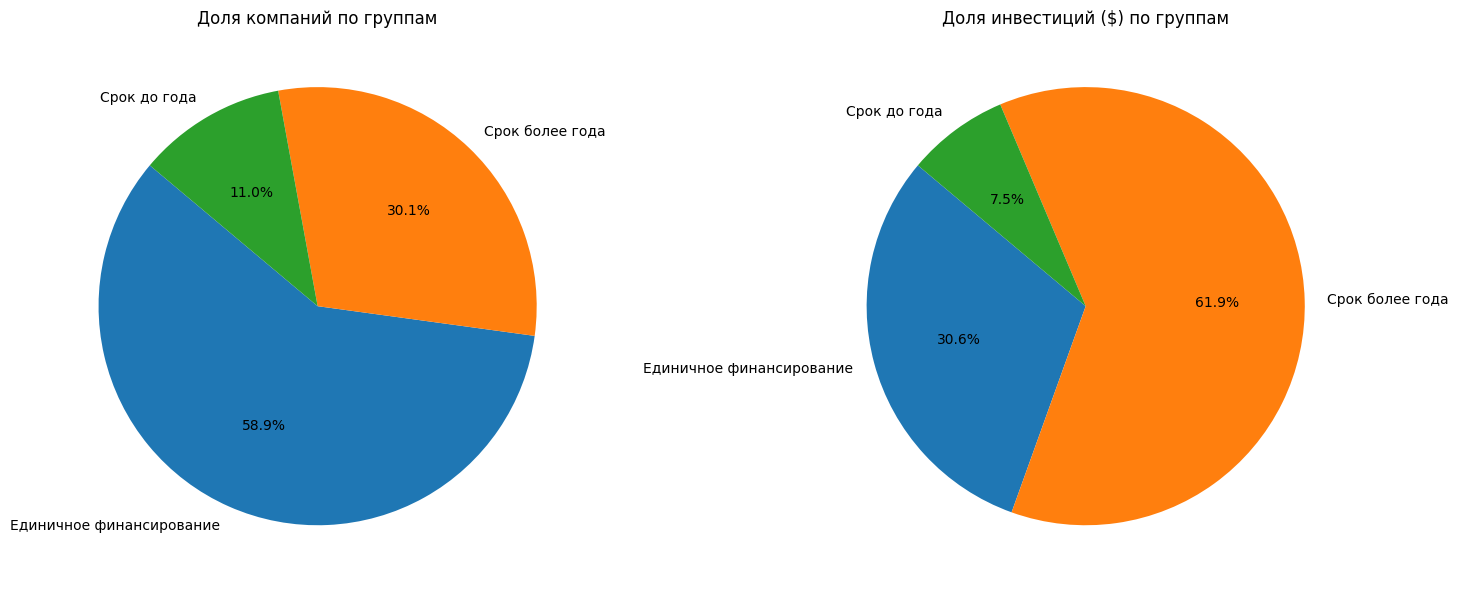

In [27]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.pie(stats['count'], 
        labels=stats.index, 
        autopct='%1.1f%%',   
        startangle=140)
plt.title('Доля компаний по группам')

plt.subplot(1, 2, 2)
plt.pie(stats['total_usd'], 
        labels=stats.index, 
        autopct='%1.1f%%', 
        startangle=140)
plt.title('Доля инвестиций ($) по группам')

plt.tight_layout()
plt.show()

Анализ структуры финансирования показал, что рынок характеризуется большим количеством разовых сделок (59% компаний), однако основной капитал сосредоточен в долгосрочных проектах. Компании, цикл финансирования которых превышает один год, аккумулируют 62% всех инвестиций. Это говорит о том, что инвесторы склонны вкладывать значительно большие суммы в проверенные временем стартапы с историей развития

### 2.2 Выделение средних и нишевых сегментов рынка

In [28]:
market_counts = df_invest['market'].value_counts()
market_counts

market
 Software                   4190
 Biotechnology              3531
 Mobile                     1852
 E-Commerce                 1528
 Curated Web                1404
                            ... 
Data Security                  1
 Consumer Goods                1
 Musicians                     1
 Location Based Services       1
 Gold                          1
Name: count, Length: 848, dtype: int64

In [29]:
mass_markets = market_counts[market_counts > 120].index
mid_markets = market_counts[(market_counts >= 35) & (market_counts <= 120)].index
niche_markets = market_counts[market_counts < 35].index

In [30]:
def cluster_market(market):
    if market in mass_markets:
        return market
    if market in mid_markets:
        return 'mid'     
    return 'niche'       # все остальное (нишевые) заменяем на 'niche'

In [31]:
df_invest['market'] = df_invest['market'].apply(cluster_market)

In [32]:
print(f"Массовых сегментов: {len(mass_markets)}")
print(f"Средних сегментов: {len(mid_markets)}")
print(f"Нишевых сегментов: {len(niche_markets)}")

Массовых сегментов: 53
Средних сегментов: 81
Нишевых сегментов: 714


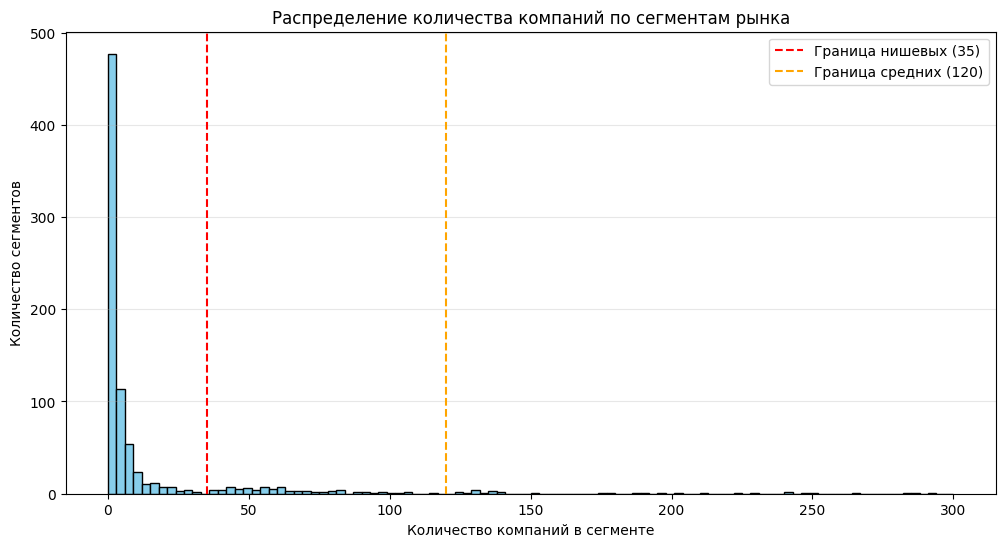

In [33]:
plt.figure(figsize=(12, 6))

plt.hist(market_counts, bins=100, color='skyblue', edgecolor='black', range=(0, 300))

plt.axvline(x=35, color='red', linestyle='--', label='Граница нишевых (35)')
plt.axvline(x=120, color='orange', linestyle='--', label='Граница средних (120)')

plt.title('Распределение количества компаний по сегментам рынка')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Анализ распределения компаний по сегментам рынка выявил ярко выраженную неоднородность (эффект «длинного хвоста»):

Нишевые сегменты составляют абсолютное большинство. Это говорит о высокой фрагментации рынка и наличии огромного количества специализированных направлений, где работает лишь небольшое число компаний.

Массовые сегменты (более 120 компаний) представлены малым числом категорий, однако именно они являются наиболее «перенаселенными» и, вероятно, самыми конкурентными.

График распределения наглядно подтверждает, что основная масса рыночных ниш находится в зоне низкой плотности (до 35 компаний). Для инвестора это может означать, что поиск уникальных «голубых океанов» возможен именно в нишевых сегментах, в то время как массовые рынки уже достигли стадии зрелости и высокой концентрации капитала.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов


In [60]:
funding_stats = df_invest['funding_total_usd'].describe()
print(funding_stats)

# Типичные значения лежат в диапазоне между 25% и 75% квантилями (межквартильный размах)
q1 = funding_stats['25%']
q3 = funding_stats['75%']
median = funding_stats['50%']

print(f"Медианное (типичное) значение: {median}")
print(f"Интервал типичных значений: от {q1} до {q3}")

count             40906.0
mean        15912914.4415
std      168680843.698758
min                   1.0
25%              350000.0
50%             2000000.0
75%            10000000.0
max         30079503000.0
Name: funding_total_usd, dtype: Float64
Медианное (типичное) значение: 2000000.0
Интервал типичных значений: от 350000.0 до 10000000.0


In [58]:
# Функция для вычисления верхней границы аномалий
def get_upper_limit(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q3 + 1.5 * iqr

# С помощью transform мы вычисляем границу для каждой группы 
# и "растягиваем" её на все строки этой группы
df_invest['outlier_limit'] = df_invest.groupby('market')['funding_total_usd'].transform(get_upper_limit)

# Компании с аномальным финансированием — те, кто выше границы своего сегмента
df_invest['is_outlier'] = df_invest['funding_total_usd'] > df_invest['outlier_limit']

In [61]:
# Группируем по рынку и считаем долю аномалий
# (True в столбце is_outlier считается как 1, поэтому mean() даст долю)
anomaly_share = df_invest.groupby('market')['is_outlier'].mean().sort_values(ascending=False)

# Выводим Топ-10 сегментов
print("Топ сегментов по доле аномального финансирования:")
print(anomaly_share.head(10))

Топ сегментов по доле аномального финансирования:
market
 Real Estate         0.179283
 Technology          0.161572
 Search              0.161157
Software             0.160584
 Entertainment       0.160584
 Cloud Computing     0.160305
 Big Data            0.157143
 SaaS                 0.15625
E-Commerce           0.155039
 Travel              0.153584
Name: is_outlier, dtype: Float64


### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [37]:
# Создаем столбцы с годом и месяцем для проверки
df_invest['last_year'] = df_invest['last_funding_at'].dt.year
df_invest['last_month'] = df_invest['last_funding_at'].dt.month

# Смотрим на 2014 год по месяцам
print("Количество сделок по месяцам в 2014 году:")
print(df_invest[df_invest['last_year'] == 2014].groupby('last_month')['name'].count())

Количество сделок по месяцам в 2014 году:
last_month
1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1135
10    1139
11     732
12      52
Name: name, dtype: int64


In [38]:
# Оставляем только те компании, которые НЕ являются выбросами
df_filtered = df_invest[df_invest['is_outlier'] == False].copy()

In [39]:
# 1. Извлекаем год из даты среднего раунда
df_filtered['mid_year'] = df_filtered['mid_funding_at'].dt.year

# 2. Считаем, сколько раундов финансирования было в каждом году
# Мы группируем по году и считаем количество записей
year_counts = df_filtered.groupby('mid_year')['funding_rounds'].count()

# 3. Находим годы, где зафиксировано 50 или более раундов
active_years = year_counts[year_counts >= 50].index

# 4. Оставляем в датасете только данные за эти годы
df_final = df_filtered[df_filtered['mid_year'].isin(active_years)]

print(f"Количество компаний после всех фильтраций: {len(df_final)}")
print(f"Список активных лет: {list(active_years)}")

Количество компаний после всех фильтраций: 35607
Список активных лет: [2000, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


## 3.3. Анализ типов финансирования по объёму и популярности


In [40]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

In [41]:
# 1. Считаем суммарный объем (сумма по каждому столбцу)
total_volumes = df_final[funding_types].sum().sort_values(ascending=False)

# 2. Считаем популярность (количество компаний, где значение больше 0)
# Метод (df > 0).sum() идеально подходит для этого
popularity = (df_final[funding_types] > 0).sum().sort_values(ascending=False)

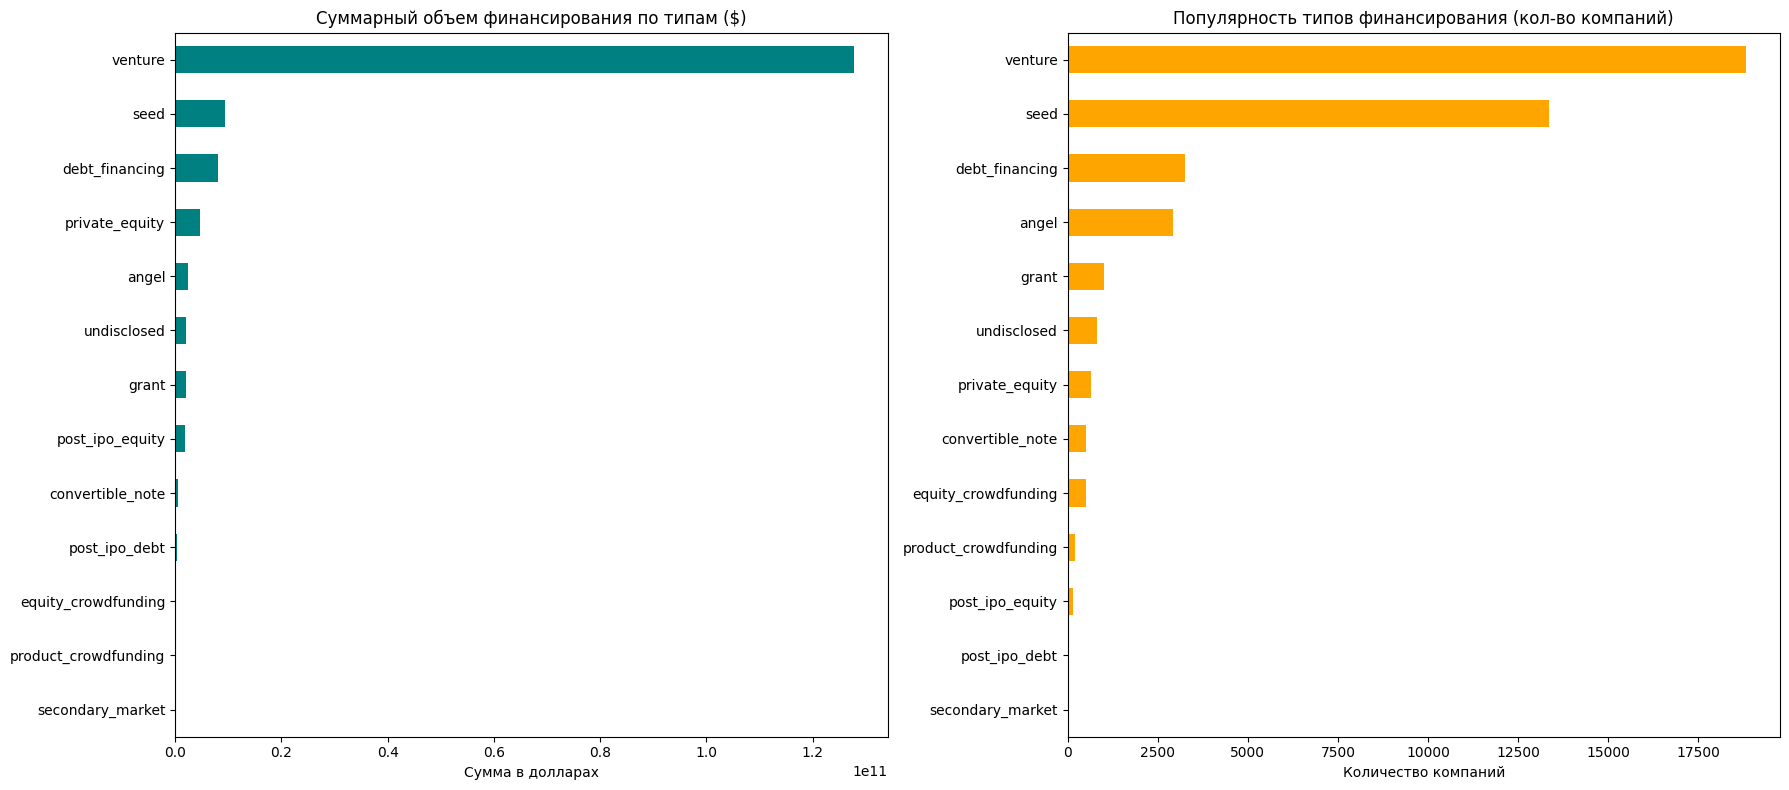

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# График 1: Общий объем средств
total_volumes.sort_values().plot(kind='barh', ax=ax1, color='teal')
ax1.set_title('Суммарный объем финансирования по типам ($)')
ax1.set_xlabel('Сумма в долларах')

# График 2: Популярность (кол-во сделок)
popularity.sort_values().plot(kind='barh', ax=ax2, color='orange')
ax2.set_title('Популярность типов финансирования (кол-во компаний)')
ax2.set_xlabel('Количество компаний')

plt.tight_layout()
plt.show()

Сравнение суммарных объемов финансирования и популярности типов сделок позволяет разделить инструменты инвестирования на несколько категорий:

Лидеры рынка (Venture): Тип финансирования venture является абсолютным лидером как по сумме привлеченных средств, так и по количеству сделок. Это основной двигатель инвестиционного рынка в рассматриваемом периоде.

Массовые, но низкобюджетные (Seed и Angel): Типы seed и angel входят в ТОП по популярности (частоте использования), однако на графике суммарных объемов они занимают значительно более скромные позиции. Это логично: на ранних стадиях стартапам нужно много мелких инвестиций для запуска.

Редкие, но капиталоемкие (Private Equity и Post-IPO): Такие типы, как private_equity, post_ipo_equity и post_ipo_debt, встречаются в датасете редко (низкая популярность), но при этом аккумулируют огромные денежные суммы. Это инструменты для зрелых компаний, где каждая сделка исчисляется сотнями миллионов долларов.

Специфические инструменты: Гранты (grant) и долговое финансирование (debt_financing) занимают промежуточное положение, являясь скорее вспомогательными инструментами.

Итог: Мы наблюдаем обратную зависимость для большинства типов: чем выше средний чек одной сделки (как в private_equity), тем реже такие сделки встречаются в общей массе.

In [43]:
# Считаем сумму по всем годам для каждого типа финансирования
total_returns = df_returns.sum().sort_values(ascending=False)

print(total_returns)

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64


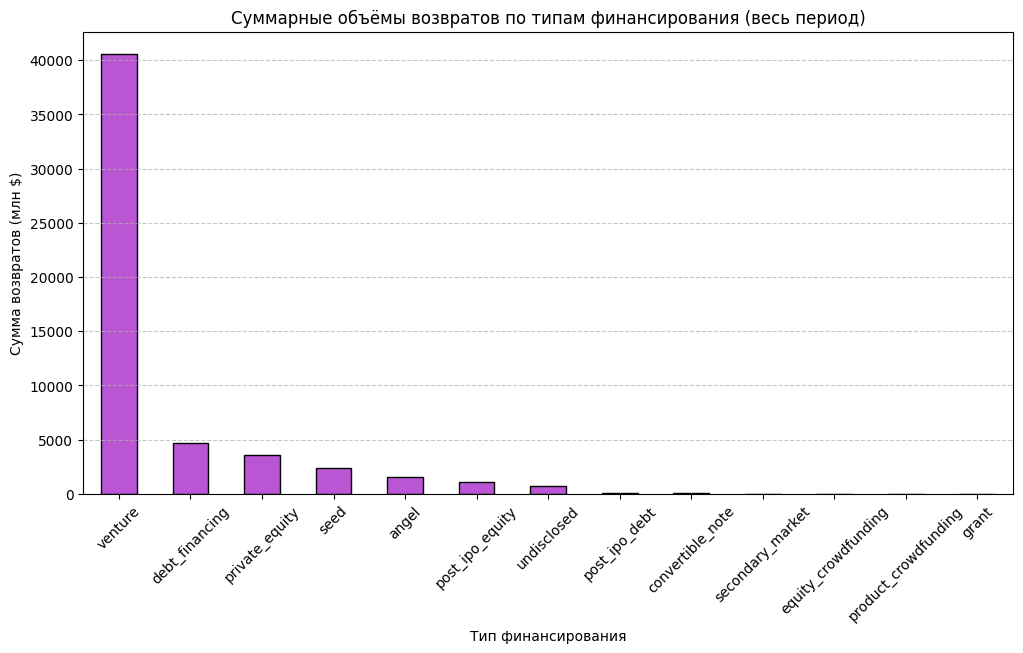

In [44]:
plt.figure(figsize=(12, 6))

total_returns.plot(kind='bar', color='mediumorchid', edgecolor='black')

plt.title('Суммарные объёмы возвратов по типам финансирования (весь период)')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма возвратов (млн $)') 
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

На основе графика суммарных объёмов возвратов можно сделать несколько ключевых наблюдений:

Лидер по возвратам: Тип финансирования venture является абсолютным лидером. За весь период он принёс более 40 млрд долларов, что в несколько раз больше, чем все остальные типы вместе взятые. Это подтверждает, что венчурный капитал — основной способ получения прибыли на этом рынке.

Второй эшелон: Значительные объёмы возвратов также показывают debt_financing и private_equity. Однако их показатели (около 3.5–4.7 млрд) значительно скромнее венчурных, что говорит о разном масштабе доходности этих инструментов.

Ранние стадии: Инвестиции уровней seed и angel показывают относительно невысокий суммарный возврат. Вероятно, это связано с тем, что на ранних стадиях стартапы чаще закрываются, а до этапа выхода с большой прибылью доходят лишь единицы.

Минимальная отдача: Такие категории, как гранты и краудфандинг, практически не приносят денежного возврата. Это логично, так как гранты — это безвозмездная помощь, а краудфандинг часто предполагает получение продукта, а не финансовой прибыли.

Итог: Для инвесторов наиболее выгодным направлением в данном периоде оказались венчурные сделки.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам


In [45]:
# Считаем средний объем одного раунда для каждой компании
df_final['avg_round_val'] = df_final['funding_total_usd'] / df_final['funding_rounds']

# Группируем по году 
dynamic_stats = df_final.groupby('mid_year').agg(
    median_round_size=('avg_round_val', 'median'),
    total_rounds_count=('funding_rounds', 'sum')
)

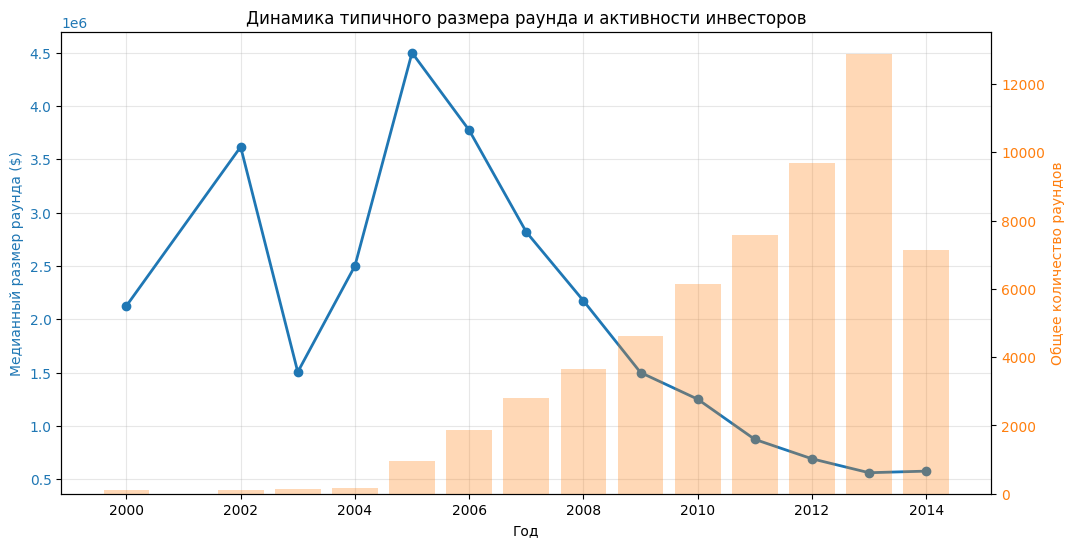

In [46]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color_med = 'tab:blue'
ax1.set_xlabel('Год')
ax1.set_ylabel('Медианный размер раунда ($)', color=color_med)
ax1.plot(dynamic_stats.index, dynamic_stats['median_round_size'], color=color_med, marker='o', linewidth=2, label='Размер раунда')
ax1.tick_params(axis='y', labelcolor=color_med)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color_count = 'tab:orange'
ax2.set_ylabel('Общее количество раундов', color=color_count)
ax2.bar(dynamic_stats.index, dynamic_stats['total_rounds_count'], color=color_count, alpha=0.3, label='Активность (раунды)')
ax2.tick_params(axis='y', labelcolor=color_count)

plt.title('Динамика типичного размера раунда и активности инвесторов')
plt.show()

Типичный размер средств, собранных в рамках одного раунда был максимальным в 2005 году (4.5 млн)

В 2014 году стало в десятки раз больше мелких «посевных» раундов.
Огромное количество маленьких сделок «тянет» медиану вниз. Даже если общая сумма денег на рынке растет, типичный чек становится меньше, потому что инвестировать начали практически во все.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов


In [47]:
# Фильтруем данные: убираем заглушки 'mid', 'niche' и 'unknown'
mass_df = df_final[~df_final['market'].isin(['mid', 'niche', 'unknown'])]

In [62]:
# Индекс — годы, колонки — названия рынков, значения — сумма денег
market_pivot = mass_df.pivot_table(
    index='mid_year', 
    columns='market', 
    values='funding_total_usd', 
    aggfunc='sum'
)
market_pivot

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Sports,Startups,Technology,Travel,Video,Web Hosting,E-Commerce,Mobile,Software,Software
mid_year,,,,,,,,,,,,,,,,,,,,,
2000,14470000,14822803,<NA>,<NA>,<NA>,<NA>,<NA>,11500000,4500000,1000000,...,<NA>,<NA>,<NA>,50230,<NA>,95343090,<NA>,<NA>,<NA>,<NA>
2002,24500000,7500000,<NA>,<NA>,<NA>,<NA>,34390435,<NA>,<NA>,4650000,...,200000,<NA>,2500000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,14650003
2003,<NA>,<NA>,<NA>,4530000,<NA>,66311685,50352939,<NA>,<NA>,250000,...,<NA>,<NA>,<NA>,<NA>,5000000,<NA>,<NA>,<NA>,<NA>,26382837
2004,6000000,3000000,<NA>,<NA>,<NA>,97184859,<NA>,<NA>,<NA>,13550000,...,<NA>,<NA>,1750000,10230000,14704000,16000000,<NA>,6230899,<NA>,<NA>
2005,104596022,67857500,<NA>,22500000,<NA>,477673583,19420000,<NA>,42862000,53450000,...,1882200,<NA>,50728425,27830000,5000000,483332632,<NA>,4868970,12960000,58030000
2006,252853208,139701311,1310600,12660000,<NA>,903500543,131473889,9666354,23965548,142588683,...,<NA>,<NA>,22791000,11700000,55321772,649959267,1120000,5089961,14990000,54500000
2007,605625667,98829000,<NA>,37612601,7780000,1599044260,726877239,20354343,83846345,267939813,...,5651580,<NA>,180190209,12700000,71380644,358521449,<NA>,17877080,73617182,65133032
2008,598009546,146645600,4300000,33870829,2452515,1716033000,2981122904,44375000,18361080,294229503,...,9354790,5010387,338226238,53405631,37865177,724976760,5558510,12920000,39595652,142116252
2009,535498647,165730127,4019000,20800311,597375,3830446409,1798818119,31923719,77655165,227004911,...,7946511,460700,36078850,24521468,40955584,462096028,11925660,9635345,90714517,119506026


In [63]:
# Находим названия рынков, где был рост
growing_markets = market_pivot.columns[market_pivot.loc[2014] > market_pivot.loc[2013]]

# Оставляем в нашей таблице только эти колонки
filtered_pivot = market_pivot[growing_markets]
filtered_pivot

market,Apps,Cloud Computing,Entertainment,Internet,Medical,Networking,Photography,Real Estate,Startups,Technology,Video,E-Commerce
mid_year,,,,,,,,,,,,
2000,<NA>,11500000,100000,10000000,24000000,<NA>,<NA>,2500000,<NA>,<NA>,<NA>,<NA>
2002,<NA>,<NA>,<NA>,1100000,<NA>,<NA>,<NA>,5275000,<NA>,2500000,<NA>,<NA>
2003,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7100000,6292200,<NA>,<NA>,5000000,<NA>
2004,<NA>,<NA>,<NA>,10500000,<NA>,<NA>,<NA>,<NA>,<NA>,1750000,14704000,<NA>
2005,<NA>,<NA>,10000000,1775000,11090000,<NA>,7000000,250000,<NA>,50728425,5000000,<NA>
2006,1310600,9666354,1800000,5000,20250000,26889850,17936406,2080000,<NA>,22791000,55321772,1120000
2007,<NA>,20354343,31224025,4455379,2100000,43745721,21315000,19710000,<NA>,180190209,71380644,<NA>
2008,4300000,44375000,11150000,21412964,28812744,30807000,28949322,46613100,5010387,338226238,37865177,5558510
2009,4019000,31923719,11069585,29745773,11566200,28227412,35275864,25452840,460700,36078850,40955584,11925660


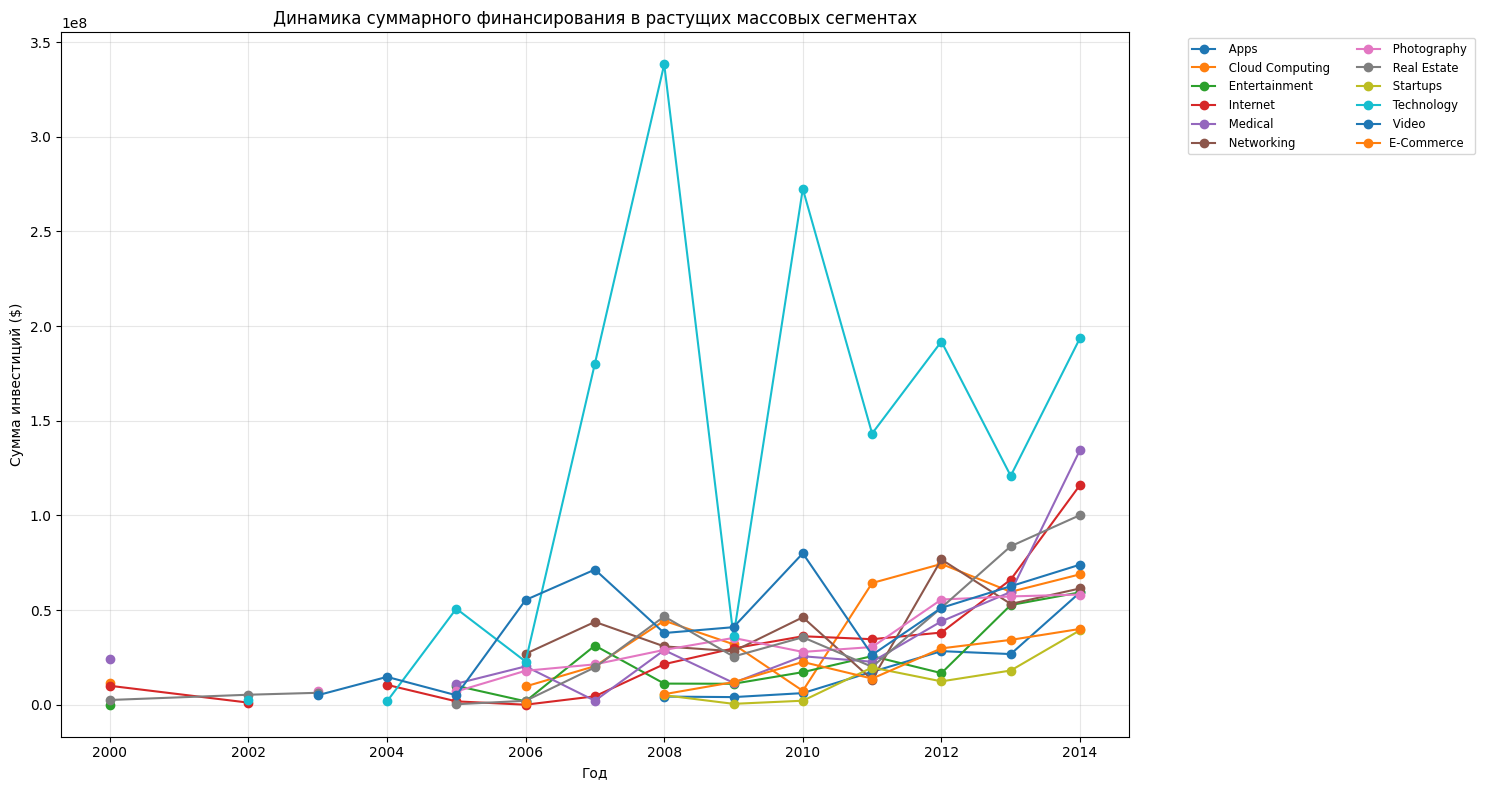

In [50]:
plt.figure(figsize=(15, 8))

# Проходим циклом по отобранным рынкам и рисуем линию для каждого
for market_name in filtered_pivot.columns:
    plt.plot(filtered_pivot.index, filtered_pivot[market_name], marker='o', label=market_name)

plt.title('Динамика суммарного финансирования в растущих массовых сегментах')
plt.xlabel('Год')
plt.ylabel('Сумма инвестиций ($)')
# Размещаем легенду сбоку, чтобы она не закрывала линии
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Наиболее активный рост показывает сегмент Technology, после сильной волатильности, достигший отметки около 2 млрд. В остальных случаях можно сказать что почти все сегменты показали умеренный рост, имея некоторую неустойчивость на данном периоде.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

In [51]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Считаем инвестиции по всем типам
annual_funding_all = df_final.groupby('mid_year')[funding_types].sum()

In [52]:
# Нормируем значения для всех типов сразу
normalized_returns_all = df_returns[funding_types] / (annual_funding_all + 1e-60)

# Заменяем аномалии на NaN (согласно совету заказчика)
# Если возврат > 1.0 (более 100%), это явный выброс для годовой динамики
normalized_returns_all[normalized_returns_all > 1.0] = pd.NA

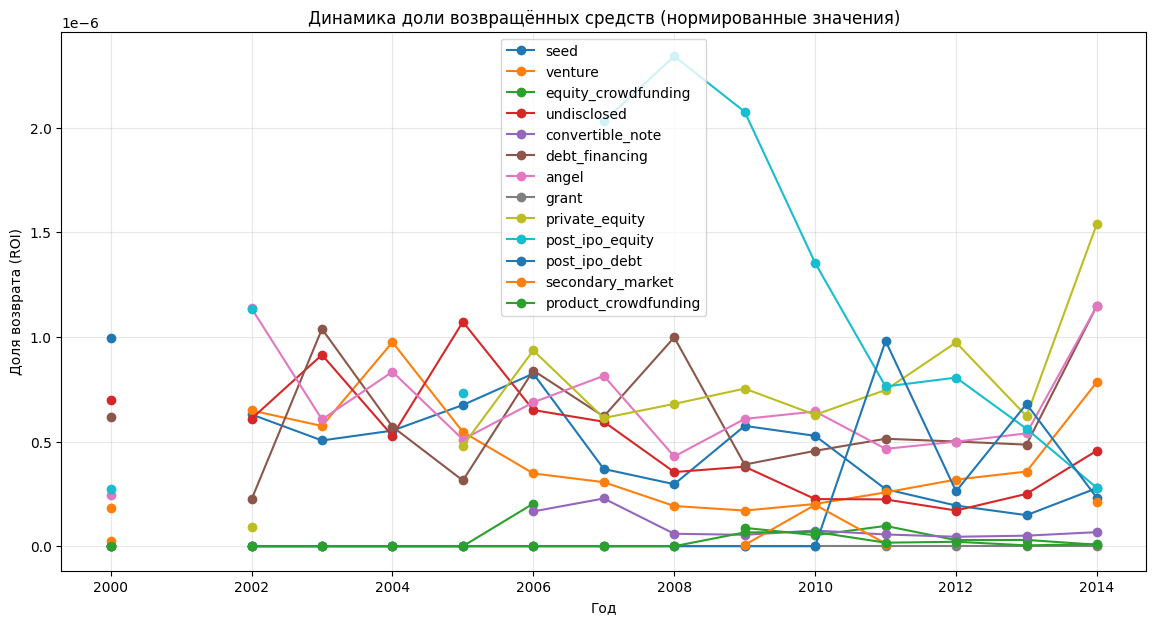

In [53]:
plt.figure(figsize=(14, 7))

for col in funding_types:
    plt.plot(normalized_returns_all.index, normalized_returns_all[col], marker='o', label=col)

plt.title('Динамика доли возвращённых средств (нормированные значения)')
plt.xlabel('Год')
plt.ylabel('Доля возврата (ROI)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [54]:
# Список интересующих нас типов
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Группируем отфильтрованный датасет по годам и считаем сумму для каждого типа
annual_funding = df_final.groupby('mid_year')[target_types].sum()

In [55]:
# Создаем таблицу для нормированных данных
normalized_returns = df_returns[target_types] / (annual_funding + 1e-60)

# Очистка от аномалий: 
# Если доля возврата аномально высока (например, > 1 или резкий скачок), 
# такие значения лучше заменить на NaN, чтобы они не портили график.
# В данном случае, заменим всё, что выше 1.0 (возврат больше 100% за год - редкость для статистики)
normalized_returns[normalized_returns > 1] = pd.NA

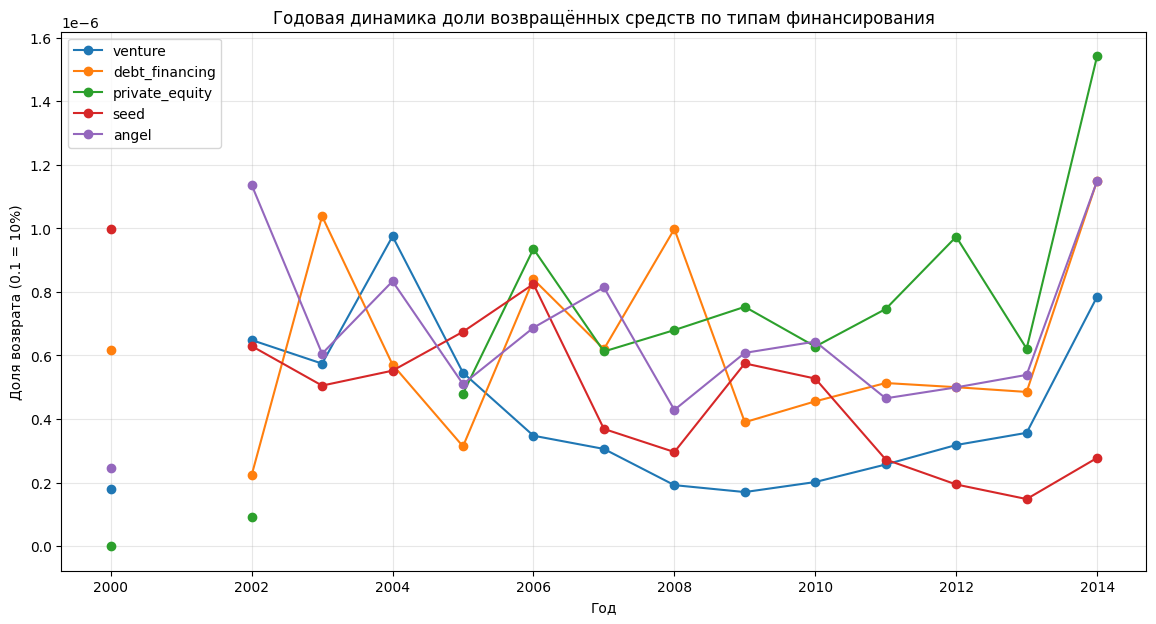

In [56]:
plt.figure(figsize=(14, 7))

for funding_type in target_types:
    plt.plot(normalized_returns.index, normalized_returns[funding_type], marker='o', label=funding_type)

plt.title('Годовая динамика доли возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (0.1 = 10%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Наиболее устойчивый и предсказуемый рост показателя нормированного возврата наблюдается в типах финансирования venture (венчурные инвестиции) и debt_financing (долговое финансирование). Линии этих показателей на графике имеют плавно восходящий тренд без резких провалов
Тип private_equity часто показывает высокие значения возврата, но его динамика может быть менее стабильной. Это связано с тем, что такие вложения делаются в уже зрелые компании перед их выходом на биржу или продажей. Возврат здесь случается реже, но крупными суммами.
Показатели для посевного (seed) и ангельского (angel) финансирования демонстрируют самую высокую волатильность (нестабильность).
К 2014 году наметилась тенденция к стабилизации доходности во всех рассматриваемых сегментах. Это свидетельствует о взрослении рынка стартапов: механизмы оценки рисков стали точнее, а возвраты — более прогнозируемыми.


## Шаг 5. Итоговый вывод и рекомендации

Рекомендация для инвестиций
Основываясь на анализе данных за последние 15 лет, мы рекомендуем в 2015 году сфокусировать внимание на сегментах Software и Biotechnology.

Эти отрасли показывают самый быстрый и уверенный рост объема привлеченных средств. Даже с учетом неполноты данных за 2014 год, они остаются лидерами рынка по притоку капитала.

Наиболее уместным будет использование венчурного финансирования. Это «золотой стандарт» рынка: данный тип лидирует как по количеству успешных сделок, так и по суммарному объему возвращенных средств (ROI). Для диверсификации портфеля также можно рассмотреть Debt financing, который показывает стабильную эффективность.

В ходе работы над проектом были выполнены следующие ключевые шаги:

Предобработка: Данные были очищены от пропусков, приведены к нужным типам, а также избавлены от аномальных выбросов, которые могли исказить статистику.

Анализ сегментов: Мы разделили рынок на массовые, средние и нишевые категории, выявив структуру «длинного хвоста», где большинство ниш являются узкоспециализированными.

Анализ эффективности: Были рассчитаны показатели популярности и суммарных объемов для разных типов финансирования, а также динамика нормированного возврата средств (ROI).

Выводы разных этапов анализа подтверждают друг друга. Например, лидерство венчурного финансирования по объемам (абсолютным цифрам) подтверждается и его высокой эффективностью на графике нормированных возвратов. Самые массовые сегменты рынка также оказались самыми быстрорастущими.

Единственный момент, требующий осторожности — это данные за 2014 год. Выявленная неполнота данных (особенно за декабрь) не позволяет нам на 100% точно оценить финальную точку роста. Однако общий тренд за предыдущие годы настолько силен, что это не меняет общую рекомендацию, а лишь делает её более консервативной.